In [157]:
from datetime import date, timedelta
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [158]:
material_id = '140000146'
cl = lambda x : x.drop('Unnamed: 0',axis=1,inplace=True)

In [159]:
forecasted = pd.read_csv('files/forecasted_final.csv')
cl(forecasted)
forecasted.Material=forecasted.Material.astype(str)

In [160]:
forecasted.head()

,Material,Desc,leadtime,max_leadtime,SAP_forecasted,year,cons_wip,cons_woip,buffer_stock,pre_net,present_stock,net_req,oem
0,100000705,GAS REFRIGERATION 404A,100.0,100.0,0.0,2025,1,1,1.0,2.0,1.0,1.0,NaN
1,100000705,GAS REFRIGERATION 404A,100.0,100.0,0.0,2026,1,1,1.0,2.0,0.0,1.0,NaN
2,100000705,GAS REFRIGERATION 404A,100.0,100.0,0.0,2027,1,1,1.0,2.0,1.0,1.0,NaN
3,100000705,GAS REFRIGERATION 404A,100.0,100.0,0.0,2028,1,1,1.0,2.0,1.0,1.0,NaN
4,100000705,GAS REFRIGERATION 404A,100.0,100.0,0.0,2029,1,1,1.0,2.0,1.0,1.0,NaN


In [161]:
forecasted.oem.value_counts()

oem
atlas    110
Name: count, dtype: int64

In [162]:
def makedaywiseForecast(df_yearly,mat,oem,end_date=date.today()+timedelta(days=365*5),initial_stock=10):
    daywiseForecast = pd.DataFrame(columns=['Material','Desc','leadtime','date','daily_cons','anticipated_consum','buffer_stock','present_stock','stock_after'])
    df=df_yearly.copy()
    df=df[(df['Material']==mat)&(df['oem']==oem)].reset_index(drop=True)
    #print(df)
    start_date = date.today()
    days = (end_date-start_date).days
    daywiseForecast.at[0,'present_stock'] = initial_stock if df.at[0,'buffer_stock'] < initial_stock else df.at[0,'buffer_stock']*1.2
    daywiseForecast.at[0,'stock_after']=daywiseForecast.at[0,'present_stock']
    reorder_point=0
    reorder_qty=0
    first_reorder=False
    leadtime = df['leadtime'].iloc[0]
    arrival={}
    for i in range(days):
        daywiseForecast.at[i,'date']=start_date+timedelta(days=i)
        daywiseForecast.at[i,'anticipated_consum']=df.loc[df['year']==date.today().year,'cons_woip'].iloc[0]*leadtime/365
        daywiseForecast.at[i,'buffer_stock']=df.loc[df['year']==date.today().year,'buffer_stock'].iloc[0]
        daywiseForecast.at[i,'daily_cons']=df.loc[df['year']==date.today().year,'cons_wip'].iloc[0]/365
        if i>0:
            if i in arrival.keys():
                arrived_qty = arrival[i]
            else:
                arrived_qty=0
            daywiseForecast.at[i,'present_stock']=max(daywiseForecast.at[i-1,'present_stock']-daywiseForecast.at[i-1,'daily_cons'],0)
            daywiseForecast.at[i,'stock_after']=max(daywiseForecast.at[i-1,'stock_after']-daywiseForecast.at[i-1,'daily_cons'],0)+arrived_qty
            if not first_reorder:
                if daywiseForecast.at[i,'present_stock']< daywiseForecast.at[i,'buffer_stock']:
                    reorder_point = daywiseForecast.at[i,'date']
                    first_reorder = True
                    current_year=daywiseForecast.at[i,'date'].year
                    reorder_qty = df.loc[df['year']==date.today().year,'cons_wip'].iloc[0] + daywiseForecast.at[i,'anticipated_consum'] +  daywiseForecast.at[i,'buffer_stock'] - daywiseForecast.at[i, 'present_stock']
                    arrival[i+leadtime]=reorder_qty
    daywiseForecast['Material']=mat
    daywiseForecast['Desc']=df.at[0,'Desc']
    daywiseForecast['leadtime']=df['leadtime'].iloc[0]
    
    return daywiseForecast,reorder_point,reorder_qty,leadtime

In [163]:
df,reorder_point,reorder_qty,leadtime = makedaywiseForecast(forecasted,material_id,'atlas')

KeyError: 0

In [ ]:
df

,Material,Desc,leadtime,date,daily_cons,anticipated_consum,buffer_stock,present_stock,stock_after
0,220027684,OIL AIR SEPERATOR KIT,605.0,2025-07-17,0.00274,1.657534,2.0,10,10
1,220027684,OIL AIR SEPERATOR KIT,605.0,2025-07-18,0.00274,1.657534,2.0,9.99726,9.99726
2,220027684,OIL AIR SEPERATOR KIT,605.0,2025-07-19,0.00274,1.657534,2.0,9.994521,9.994521
3,220027684,OIL AIR SEPERATOR KIT,605.0,2025-07-20,0.00274,1.657534,2.0,9.991781,9.991781
4,220027684,OIL AIR SEPERATOR KIT,605.0,2025-07-21,0.00274,1.657534,2.0,9.989041,9.989041
...,...,...,...,...,...,...,...,...,...
1820,220027684,OIL AIR SEPERATOR KIT,605.0,2030-07-11,0.00274,1.657534,2.0,5.013699,5.013699
1821,220027684,OIL AIR SEPERATOR KIT,605.0,2030-07-12,0.00274,1.657534,2.0,5.010959,5.010959
1822,220027684,OIL AIR SEPERATOR KIT,605.0,2030-07-13,0.00274,1.657534,2.0,5.008219,5.008219
1823,220027684,OIL AIR SEPERATOR KIT,605.0,2030-07-14,0.00274,1.657534,2.0,5.005479,5.005479


In [ ]:
reorder_point,reorder_qty

(0, 0)

In [ ]:
def plot_req2(dff,tagw,mat,ro_p,leadtime):
  result=dff.copy()
  plt.figure(figsize=(12, 4))
  for t in tagw:
    t1=result[t].to_list()
    y1=result['date'].to_list()
    # print(t1, y1)
    plt.plot(y1,t1, label=t,marker='o', linestyle='-')
  plt.axvline(x=ro_p, color='red', linestyle='--', label=f"reorder point at {ro_p.strftime('%d-%m-%Y')}")
  plt.axvline(x=ro_p+timedelta(days=leadtime), color='red', linestyle='--', label=f"delivery point at {(ro_p+timedelta(days=leadtime)).strftime('%d-%m-%Y')}")
  plt.hlines(50, ro_p, ro_p+timedelta(days=leadtime), colors='k', linestyles='--', label='leadtime')
  plt.xticks(ticks=y1, labels=y1, rotation=45)
  plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  plt.legend()
  plt.title(f"Forecast - {mat}")
  plt.tight_layout()
  plt.savefig(f"{mat}_1.png")
  plt.show()

AttributeError: 'int' object has no attribute 'strftime'

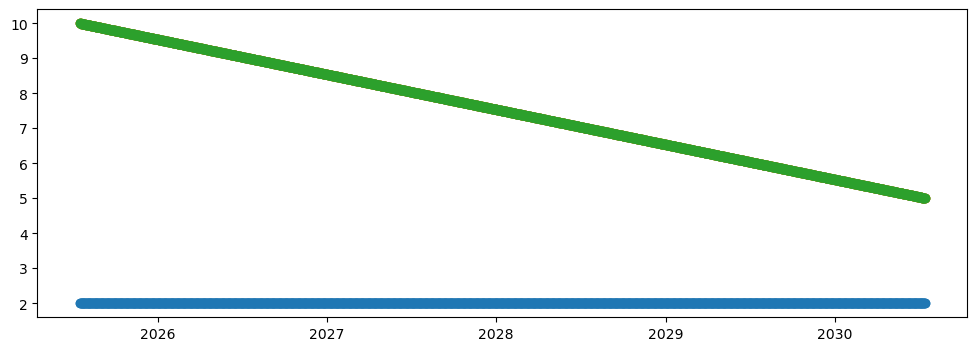

In [ ]:
plot_req2(df,['buffer_stock','stock_after','present_stock'],material_id,reorder_point,leadtime)